## 1.Import Necessary libraris

In [60]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score,calinski_harabasz_score,accuracy_score,precision_score,recall_score,confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

## 2.Import Dataset

In [2]:
college_data = pd.read_csv("college_list.csv")
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9
...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6


## 3.Data Understanding

In [3]:
college_data.shape

(500, 6)

In [4]:
college_data.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64

In [5]:
college_data["College_Name"].nunique()

500

## 4.Data Preppuration 

In [6]:
x = college_data.drop(labels="College_Name",axis=1)
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


In [7]:
std_sclae = StandardScaler()
x_scaled = std_sclae.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled)
x_scaled

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [8]:
x_scaled.mean().round(4),x_scaled.std().round(4)

(0    0.0
 1    0.0
 2   -0.0
 3    0.0
 4   -0.0
 dtype: float64,
 0    1.001
 1    1.001
 2    1.001
 3    1.001
 4    1.001
 dtype: float64)

## 5.Model Building

In [9]:
kmean_cluster = KMeans(n_clusters=3,random_state=56)
kmean_cluster.fit(x_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",56
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 5)","[

In [10]:
kmean_cluster.labels_

array([0, 2, 0, 0, 0, 2, 1, 2, 0, 1, 2, 1, 0, 1, 2, 2, 1, 0, 1, 1, 2, 1,
       2, 2, 1, 2, 1, 2, 0, 2, 2, 1, 1, 0, 0, 2, 1, 2, 0, 1, 2, 1, 2, 2,
       1, 2, 0, 2, 2, 1, 0, 1, 2, 0, 0, 2, 0, 2, 0, 1, 1, 0, 2, 0, 1, 2,
       2, 1, 0, 0, 0, 2, 2, 0, 1, 2, 1, 2, 0, 0, 1, 2, 2, 1, 1, 1, 2, 1,
       0, 0, 1, 1, 1, 0, 2, 2, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 0, 2, 0, 1, 1, 0, 0, 0, 2, 0, 0, 0,
       2, 0, 1, 2, 1, 0, 0, 1, 2, 0, 0, 2, 1, 2, 2, 1, 0, 2, 2, 1, 0, 0,
       2, 2, 1, 0, 0, 2, 2, 1, 0, 0, 1, 1, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 1, 2, 0, 1, 0, 0, 1, 0, 0, 2, 2, 0, 0, 1, 0, 1, 0, 2, 0, 2, 2,
       0, 0, 1, 2, 1, 0, 2, 1, 1, 2, 1, 1, 2, 1, 0, 0, 2, 1, 2, 0, 2, 1,
       2, 2, 1, 2, 1, 1, 0, 1, 2, 0, 1, 1, 2, 1, 1, 0, 2, 2, 2, 2, 0, 1,
       2, 0, 1, 1, 1, 0, 0, 2, 1, 2, 1, 2, 2, 0, 2, 1, 1, 1, 0, 0, 0, 2,
       1, 2, 0, 1, 2, 1, 0, 2, 0, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 1, 1, 0,
       1, 0, 2, 0, 1, 2, 2, 2, 0, 0, 1, 2, 2, 1, 1,

### Clustering is DONE here. Let's put this back to the original Dataset for further Data Mining Operations

## ==========================================================================================

In [11]:
college_data["college_level"] = kmean_cluster.labels_
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,0
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,2
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0
...,...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,2
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,0
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3,1
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,0


## Finding Cluster Centroid

In [12]:
kmean_cluster.cluster_centers_

array([[-0.61930466, -0.0277593 , -0.07170584, -0.11741908,  0.85823294],
       [-0.40068242,  0.26736981,  0.4122993 , -0.17424837, -0.911228  ],
       [ 1.05686238, -0.22925856, -0.32233935,  0.29566261, -0.04281695]])

In [13]:
x["college_level"] = kmean_cluster.labels_ 
x.head()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level
0,14,113042,59,9.20,8,0
1,27,115999,67,3.07,7,2
2,22,47955,50,3.40,9,0
3,18,67841,43,4.64,8,0
4,15,100640,54,4.66,9,0


### Note: This is the Most Important Data Mining Step post Clustering, but before we give labels

In [14]:
x.groupby(by="college_level").mean().round(4)

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
college_level,,,,,
0,13.9492,136990.8701,67.7684,6.6494,7.6949
1,15.4088,155839.2075,76.0818,6.4838,4.1509
2,25.1402,124122.1768,63.4634,7.8536,5.8902


In [15]:
x.groupby(by="college_level").agg(["min","max","mean"]).round(2)

Student_Faculty_Ratio            Annual_Fees_INR          \
                                min max   mean             min     max   
college_level                                                            
0                                 8  27  13.95           31015  249930   
1                                 8  29  15.41           31605  247841   
2                                15  29  25.14           30404  249536   

                         Placement_Percentage            Average_Package_LPA  \
                    mean                  min max   mean                 min   
college_level                                                                  
0              136990.87                   40  98  67.77                2.00   
1              155839.21                   40  99  76.08                2.01   
2              124122.18                   40  99  63.46                2.01   

                           Infrastructure_Score            
                 max  mean                  min max  mean  
college_level                                              
0              11.90  6.65                    5   9  7.69  
1              11.96  6.48                    3   7  4.15  
2              11.99  7.85                    3   9  5.89

In [16]:
cluster_name = {0:"Best Colleges",
                1:"Mid-Level Colleges",
                2:"Emerging / Lower-Level Colleges"}
x["Category"] = x["college_level"].map(cluster_name)

In [17]:
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level,Category
0,14,113042,59,9.20,8,0,Best Colleges
1,27,115999,67,3.07,7,2,Emerging / Lower-Level Colleges
2,22,47955,50,3.40,9,0,Best Colleges
3,18,67841,43,4.64,8,0,Best Colleges
4,15,100640,54,4.66,9,0,Best Colleges
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,2,Emerging / Lower-Level Colleges
496,12,39111,76,3.62,7,0,Best Colleges
497,16,199182,64,3.88,3,1,Mid-Level Colleges
498,10,46389,77,9.31,6,0,Best Colleges


## =========================================================================================

### But, how to decide the Optimal Number of Clusters?

In [53]:
kmean_cluster = KMeans(n_clusters=3,random_state=56)
kmean_cluster.fit(x_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",56
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 5)","[

In [19]:
kmean_cluster.inertia_

1874.0043479674378

#### The K-means algorithm aims to choose centroids that minimise the inertia, or within-cluster sum-of-squares criterion:

In [20]:
wcss = []
for i in range(1,11):
    kmean_cluster = KMeans(n_clusters=i,random_state=56)
    kmean_cluster.fit(x_scaled)
    wcss.append(kmean_cluster.inertia_) 
wcss    

[2500.0000000000005,
 2126.1240798623926,
 1874.0043479674378,
 1675.3387795211886,
 1502.3697305150213,
 1362.1442148467274,
 1338.0464461966005,
 1228.7352483403859,
 1151.5753422500002,
 1063.3274884594298]

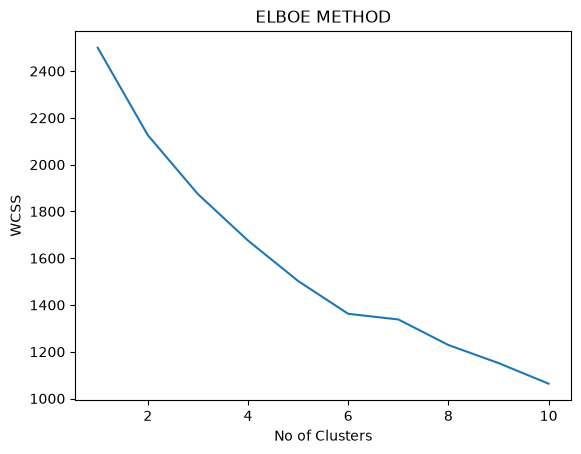

In [21]:
plt.plot(range(1,11),wcss)
plt.title("ELBOE METHOD")
plt.xlabel("No of Clusters")
plt.ylabel("WCSS")
plt.show()

In [22]:
silhouette_score(x_scaled,kmean_cluster.labels_)

0.1803528408802036

In [23]:
x_scaled

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [45]:
s_score= []
for i in range(2,11):
    kmean_cluster_1 = KMeans(n_clusters=i,random_state=56,n_init="auto")
    lable = kmean_cluster_1.fit_predict(x_scaled)
    score=silhouette_score(x_scaled,lable)
    s_score.append(score)
    print(f"K = {i}, Silhouette Score = {score:.3f}")
print(s_score)

K = 2, Silhouette Score = 0.145
K = 3, Silhouette Score = 0.142
K = 4, Silhouette Score = 0.150
K = 5, Silhouette Score = 0.163
K = 6, Silhouette Score = 0.170
K = 7, Silhouette Score = 0.149
K = 8, Silhouette Score = 0.166
K = 9, Silhouette Score = 0.170
K = 10, Silhouette Score = 0.180
[0.14545117740624203, 0.14197975469175345, 0.15020169845715464, 0.1627595509141021, 0.17027877926052815, 0.14896736550094125, 0.1660998715994373, 0.16979115321566415, 0.1803528408802036]


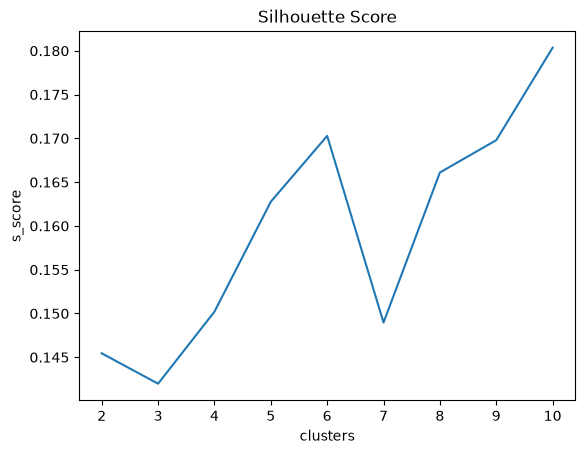

In [47]:
plt.plot(range(2,11),s_score)
plt.title("Silhouette Score")
plt.xlabel("clusters")
plt.ylabel("s_score")
plt.show()

| Score              | Meaning                            |
| ------------------ | ---------------------------------- |
| 🟣 Close to **+1** | Very good clustering               |
| 🟢 Around **0**    | Clusters overlap                   |
| 🔴 Less than **0** | Points may be in the wrong cluster |


In [29]:
calinski_harabasz_score(x_scaled,kmean_cluster.labels_)

73.56043889428278

In [40]:
ch_score = []
for i in range(2,11):
    kmean_cluster = KMeans(n_clusters=i,random_state=56,n_init="auto")
    lable = kmean_cluster.fit_predict(x_scaled)
    score=calinski_harabasz_score(x_scaled,lable)
    ch_score.append(score)
    print(f"K = {i}, calinski_harabasz_score = {score:.3f}")
print(ch_score)

K = 2, calinski_harabasz_score = 87.573
K = 3, calinski_harabasz_score = 83.009
K = 4, calinski_harabasz_score = 81.383
K = 5, calinski_harabasz_score = 82.175
K = 6, calinski_harabasz_score = 82.532
K = 7, calinski_harabasz_score = 71.353
K = 8, calinski_harabasz_score = 72.718
K = 9, calinski_harabasz_score = 71.866
K = 10, calinski_harabasz_score = 73.560
[87.5725974753925, 83.00936958807671, 81.38293586892549, 82.17467600764584, 82.5317542355772, 71.3531661093658, 72.71847311073054, 71.86639061557783, 73.56043889428278]


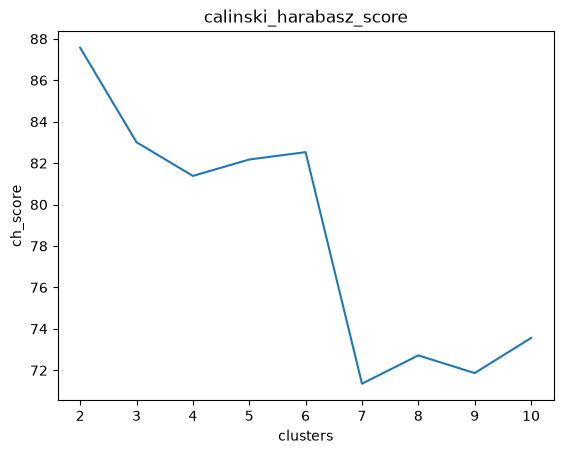

In [42]:
plt.plot(range(2,11),ch_score)
plt.title("calinski_harabasz_score")
plt.xlabel("clusters")
plt.ylabel("ch_score")
plt.show()

## LEVEL 3: Now it's time to Transition to Supervised Learning

In [67]:
x_scaled

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [69]:
y = kmean_cluster.labels_
y

array([0, 2, 0, 0, 0, 2, 1, 2, 0, 1, 2, 1, 0, 1, 2, 2, 1, 0, 1, 1, 2, 1,
       2, 2, 1, 2, 1, 2, 0, 2, 2, 1, 1, 0, 0, 2, 1, 2, 0, 1, 2, 1, 2, 2,
       1, 2, 0, 2, 2, 1, 0, 1, 2, 0, 0, 2, 0, 2, 0, 1, 1, 0, 2, 0, 1, 2,
       2, 1, 0, 0, 0, 2, 2, 0, 1, 2, 1, 2, 0, 0, 1, 2, 2, 1, 1, 1, 2, 1,
       0, 0, 1, 1, 1, 0, 2, 2, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 0, 2, 0, 1, 1, 0, 0, 0, 2, 0, 0, 0,
       2, 0, 1, 2, 1, 0, 0, 1, 2, 0, 0, 2, 1, 2, 2, 1, 0, 2, 2, 1, 0, 0,
       2, 2, 1, 0, 0, 2, 2, 1, 0, 0, 1, 1, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 1, 2, 0, 1, 0, 0, 1, 0, 0, 2, 2, 0, 0, 1, 0, 1, 0, 2, 0, 2, 2,
       0, 0, 1, 2, 1, 0, 2, 1, 1, 2, 1, 1, 2, 1, 0, 0, 2, 1, 2, 0, 2, 1,
       2, 2, 1, 2, 1, 1, 0, 1, 2, 0, 1, 1, 2, 1, 1, 0, 2, 2, 2, 2, 0, 1,
       2, 0, 1, 1, 1, 0, 0, 2, 1, 2, 1, 2, 2, 0, 2, 1, 1, 1, 0, 0, 0, 2,
       1, 2, 0, 1, 2, 1, 0, 2, 0, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 1, 1, 0,
       1, 0, 2, 0, 1, 2, 2, 2, 0, 0, 1, 2, 2, 1, 1,

In [59]:
rf_model = RandomForestClassifier(n_estimators=100,max_depth=7)
rf_model.fit(x_scaled,kmean_cluster.labels_)
y_pred = rf_model.predict(x_scaled)

In [83]:
#Model Evaluation
print("Accuracy score:",accuracy_score(y,y_pred))
print("Precision score:",round(precision_score(y,y_pred,average='macro'),3))
print("Recall score:",round(recall_score(y,y_pred,average='macro'),3))
print("Confution matrics:\n",confusion_matrix(y,y_pred))

Accuracy score: 0.998
Precision score: 0.998
Recall score: 0.998
Confution matrics:
 [[176   1   0]
 [  0 159   0]
 [  0   0 164]]


# THE END!!!!